# SAP Attention — Cell-Type Importance Analysis (20-Seed × 3-Fold CV)

Mirrors `kong_embeddings_analysis/.../cell_type_importance_attention_latest.ipynb`
for the **SAP** (single-level attention pooling) model trained in
`sap_ha_mirrored_20seeds_3fold_cv.ipynb`.

- SAP has a single learned attention head over cells per donor (`w_c`, sums to 1).
- Outer-test donors per seed play the role of "validation donors per fold".
- 20 seeds × ~10 outer-test donors ≈ 200 (seed, donor) evaluations.


## Setup

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from torch_geometric.nn import global_add_pool, global_mean_pool
from torch_geometric.utils import softmax as pyg_softmax

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, " Device:", DEVICE)


Torch: 2.8.0  Device: cpu


## Configuration

In [2]:
DATA_PATH      = "../data_healthy_inflamed/kong_5000_healthy_inflamed_5000hvg.h5ad"
PATIENT_ID_KEY = "donor_id"
LABEL_KEY      = "Type"
CELL_TYPE_KEY  = "Celltype"
EMBEDDING_KEY  = "X_scGPT"
LABEL_MAP      = {"Heal": 0, "Infl": 1}
LABEL_NAMES    = {0: "Normal", 1: "Inflamed"}
DISEASE_PALETTE = {"Normal": "#1f77b4", "Inflamed": "#e74c3c"}
NUM_CLASSES    = 2

ATTN           = True
N_HID          = 256
N_LAYERS_LIN   = 1
DROPOUT        = 0.3

SEEDS          = list(range(20))
TEST_SIZE      = 6

CKPT_DIR       = "checkpoints_20seeds"
CKPT_PATTERN   = "best_sap_ha_mirrored_model_seed{seed:02d}.pt"
OUTPUT_DIR     = "results/sap_celltype_importance"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MIN_DONORS_PER_CT = 3
THRESHOLD = 0.80

print("Output dir:", OUTPUT_DIR)


Output dir: results/sap_celltype_importance


## SAPModel — instrumented to return per-cell attention

In [3]:
class SAPModel(nn.Module):
    """Same as training SAPModel, but forward also returns per-cell weights."""
    def __init__(self, n_in, n_out=2, attn=True, dropout=0.0,
                 n_layers_lin=1, n_hid=256):
        super().__init__()
        self.attn = attn
        layers = []
        for i in range(n_layers_lin):
            c_in = n_in if i == 0 else n_hid
            layers += [nn.Linear(c_in, n_hid), nn.ReLU(), nn.Dropout(dropout)]
        self.lin = nn.Sequential(*layers)
        curr_in = n_in if len(self.lin) == 0 else n_hid
        self.w_c = nn.Sequential(nn.Linear(curr_in, 1), nn.Dropout(dropout))
        self.lin_out = nn.Linear(curr_in, n_out)

    def forward(self, X, batch, n_patients):
        X = self.lin(X)
        if self.attn:
            scores = self.w_c(X).squeeze(-1)
            w_c = pyg_softmax(scores, batch)
            X_pool = global_add_pool(X * w_c.unsqueeze(-1), batch, size=n_patients)
        else:
            w_c = None
            X_pool = global_mean_pool(X, batch, size=n_patients)
        logits = self.lin_out(X_pool)
        return logits, w_c


## Load data + donor → (cell-type vector, embeddings)

In [4]:
adata = sc.read_h5ad(DATA_PATH)
adata.obs["label"] = adata.obs[LABEL_KEY].map(LABEL_MAP).astype(int)
emb = adata.obsm[EMBEDDING_KEY]
N_FEATURES = emb.shape[1]

df = pd.DataFrame(emb, index=adata.obs.index)
df["patient"]   = adata.obs[PATIENT_ID_KEY].values
df["cell_type"] = adata.obs[CELL_TYPE_KEY].values
df["label"]     = adata.obs["label"].values

samples = (df[["patient", "label"]].drop_duplicates()
                                   .reset_index(drop=True))
all_labels = samples["label"].values
print(f"# donors: {len(samples)}  # cells: {len(df)}  # features: {N_FEATURES}")
print(samples["label"].value_counts().rename(index=LABEL_NAMES))

# donor -> (cell_type vector, embedding matrix)
donor_ct_lookup = {}
donor_emb_lookup = {}
for did, sub in df.groupby("patient", sort=False):
    donor_ct_lookup[did]  = sub["cell_type"].to_numpy()
    donor_emb_lookup[did] = sub.iloc[:, :N_FEATURES].to_numpy(dtype=np.float32)


# donors: 50  # cells: 250000  # features: 512
label
Crohn disease    36
Normal           14
Name: count, dtype: int64


## Extract per-cell attention across all 20 seeds (outer-test donors)

In [5]:
@torch.no_grad()
def extract_seed(seed_id):
    ckpt = os.path.join(CKPT_DIR, CKPT_PATTERN.format(seed=seed_id))
    if not os.path.exists(ckpt):
        print(f"  seed {seed_id:>2}: MISSING {ckpt} — skipping")
        return None

    sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed_id)
    _, ote_idx = next(sss.split(np.arange(len(samples)), all_labels))
    ote = samples.iloc[ote_idx].reset_index(drop=True)

    # Build flat tensors
    Xs, batches = [], []
    for i, p in enumerate(ote["patient"].tolist()):
        Xs.append(donor_emb_lookup[p])
        batches.append(np.full(len(donor_emb_lookup[p]), i, dtype=np.int64))
    X = torch.tensor(np.concatenate(Xs), dtype=torch.float).to(DEVICE)
    b = torch.tensor(np.concatenate(batches), dtype=torch.long).to(DEVICE)

    model = SAPModel(n_in=N_FEATURES, n_out=NUM_CLASSES, attn=ATTN,
                     dropout=DROPOUT, n_layers_lin=N_LAYERS_LIN, n_hid=N_HID).to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    model.eval()
    logits, w_c = model(X, b, len(ote))
    w_np = w_c.cpu().numpy()
    b_np = b.cpu().numpy()

    out = []
    for i, p in enumerate(ote["patient"].tolist()):
        mask = b_np == i
        weights = w_np[mask]
        ctypes  = donor_ct_lookup[p][:len(weights)]
        out.append({
            "seed": seed_id, "donor_id": p,
            "disease": LABEL_NAMES[int(ote.iloc[i]["label"])],
            "weights": weights, "cell_types": ctypes,
            "n_cells": len(weights),
        })
    return out


all_records = []
for s in SEEDS:
    rec = extract_seed(s)
    if rec is not None:
        all_records.extend(rec)
        print(f"  seed {s:>2}: extracted {len(rec)} donors")
print(f"\nTotal donor-evaluations: {len(all_records)}")


  seed  0: extracted 10 donors
  seed  1: extracted 10 donors
  seed  2: extracted 10 donors


  seed  3: extracted 10 donors
  seed  4: extracted 10 donors
  seed  5: extracted 10 donors


  seed  6: extracted 10 donors
  seed  7: extracted 10 donors
  seed  8: extracted 10 donors


  seed  9: extracted 10 donors
  seed 10: extracted 10 donors
  seed 11: extracted 10 donors


  seed 12: extracted 10 donors
  seed 13: extracted 10 donors
  seed 14: extracted 10 donors


  seed 15: extracted 10 donors
  seed 16: extracted 10 donors
  seed 17: extracted 10 donors


  seed 18: extracted 10 donors
  seed 19: extracted 10 donors

Total donor-evaluations: 200


## Build long-format DataFrames (mean per CT, per-cell raw, concentration)

In [6]:
records_mean, records_raw, conc_records = [], [], []

for r in all_records:
    w  = r["weights"]
    ct = r["cell_types"]
    n  = len(w)
    uniform_w = 1.0 / n

    # Mean per cell type
    for c in np.unique(ct):
        m = ct == c
        records_mean.append({
            "donor_id": r["donor_id"], "disease": r["disease"], "seed": r["seed"],
            "cell_type": c, "mean_attention": float(w[m].mean()),
            "n_cells_ct": int(m.sum()), "n_cells_total": n,
            "attention_fraction": float(w[m].sum()),
            "expected_fraction":  float(m.sum() / n),
        })
        # Raw per cell (subsample if very large)
        for wi in w[m]:
            records_raw.append({
                "donor_id": r["donor_id"], "disease": r["disease"], "seed": r["seed"],
                "cell_type": c, "weight": float(wi),
            })

    # Concentration metrics per donor-evaluation
    sw = np.sort(w)
    gini = (2 * np.sum(np.arange(1, n+1) * sw) - (n+1)) / (n * sw.sum())
    entropy = -(w * np.log(w + 1e-10)).sum()
    norm_entropy = entropy / np.log(n)
    k1, k5, k10 = max(1,int(0.01*n)), max(1,int(0.05*n)), max(1,int(0.1*n))
    conc_records.append({
        "donor_id": r["donor_id"], "disease": r["disease"], "seed": r["seed"],
        "n_cells": n, "norm_entropy": norm_entropy, "gini": gini,
        "top1_pct_conc": float(sw[-k1:].sum()),
        "top5_pct_conc": float(sw[-k5:].sum()),
        "top10_pct_conc": float(sw[-k10:].sum()),
        "max_vs_uniform": float(w.max() / uniform_w),
    })

df_mean = pd.DataFrame(records_mean)
df_raw  = pd.DataFrame(records_raw)
df_conc = pd.DataFrame(conc_records)

df_mean.to_csv(os.path.join(OUTPUT_DIR, "sap_attention_mean_per_donor_celltype.csv"), index=False, float_format="%.6f")
df_conc.to_csv(os.path.join(OUTPUT_DIR, "sap_attention_concentration.csv"),            index=False, float_format="%.4f")
# df_raw not saved (can be 1M+ rows)
print(f"df_mean: {len(df_mean):,}  df_raw: {len(df_raw):,}  df_conc: {len(df_conc):,}")


df_mean: 11,042  df_raw: 1,000,000  df_conc: 200


## Sanity check — do per-cell attention weights sum to 1 per donor?

In [7]:
sums = np.array([r["weights"].sum() for r in all_records])
print(f"Per-donor weight sums: min={sums.min():.6f}  max={sums.max():.6f}  mean={sums.mean():.6f}")
print("(Expected ≈ 1.0)")


Per-donor weight sums: min=0.999997  max=1.000003  mean=1.000000
(Expected ≈ 1.0)


## Distribution Plot 1 — Per-cell attention weight distribution per seed (5×4 grid)

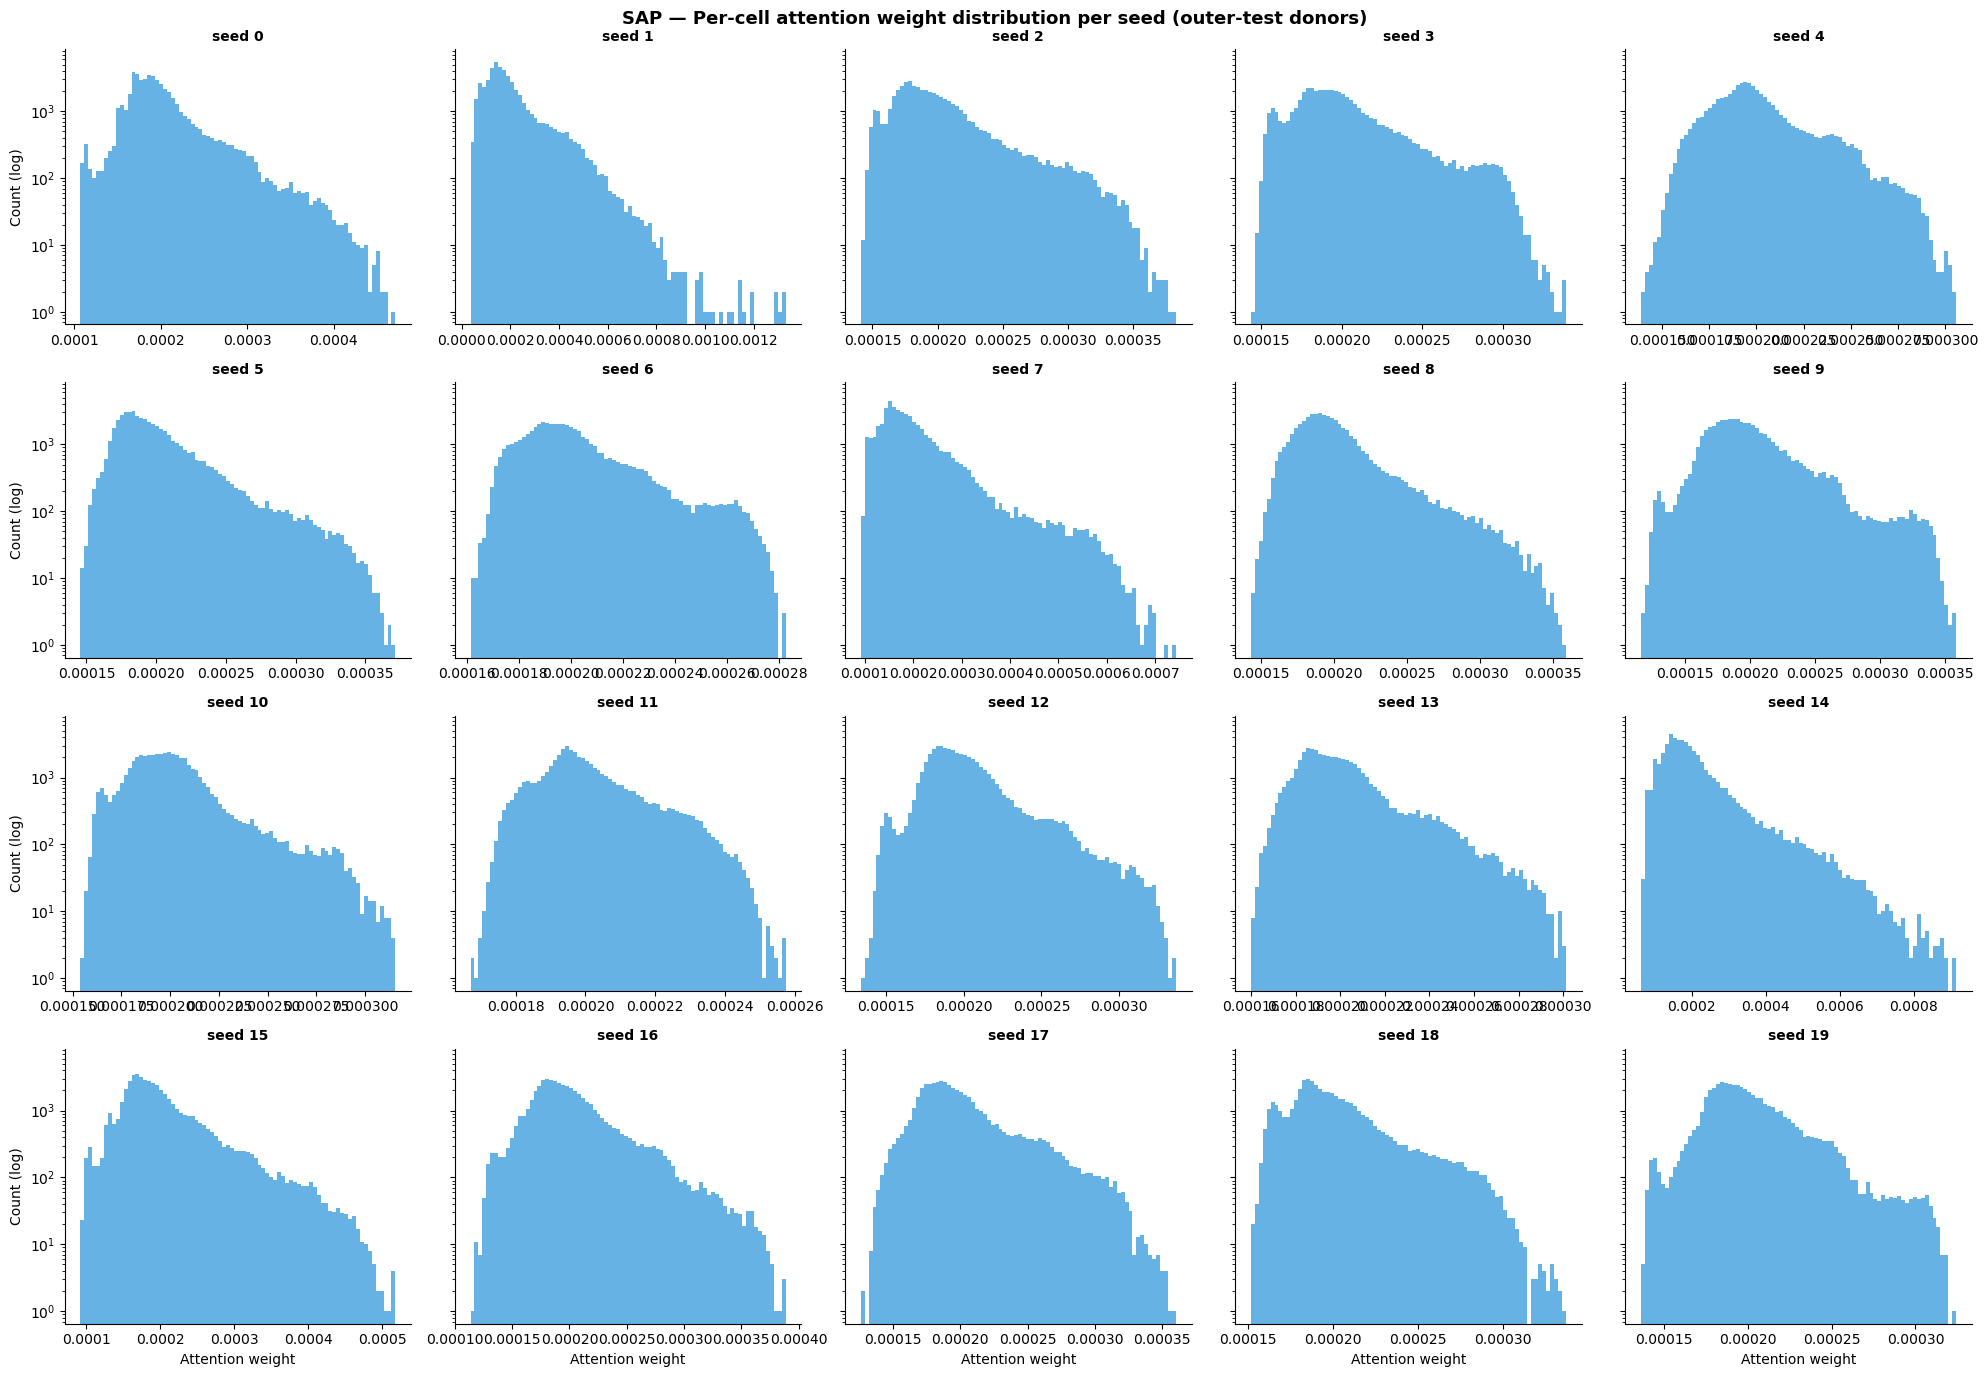

Saved -> results/sap_celltype_importance/fig_dist_per_cell_per_seed.png


In [8]:
fig, axes = plt.subplots(4, 5, figsize=(20, 14), sharey=True)
for ax, s in zip(axes.flat, SEEDS):
    ws = np.concatenate([r["weights"] for r in all_records if r["seed"] == s]) if any(r["seed"]==s for r in all_records) else np.array([])
    if len(ws):
        ax.hist(ws, bins=80, color="#3498db", alpha=0.75, edgecolor="none")
    ax.set_title(f"seed {s}", fontsize=10, fontweight="bold")
    ax.set_yscale("log")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
for ax in axes[-1,:]: ax.set_xlabel("Attention weight")
for ax in axes[:,0]:  ax.set_ylabel("Count (log)")
fig.suptitle("SAP — Per-cell attention weight distribution per seed (outer-test donors)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "fig_dist_per_cell_per_seed.png")
plt.savefig(out, dpi=140, bbox_inches="tight"); plt.show()
print("Saved ->", out)


## Distribution Plot 2 — Combined per-cell attention, colored by disease

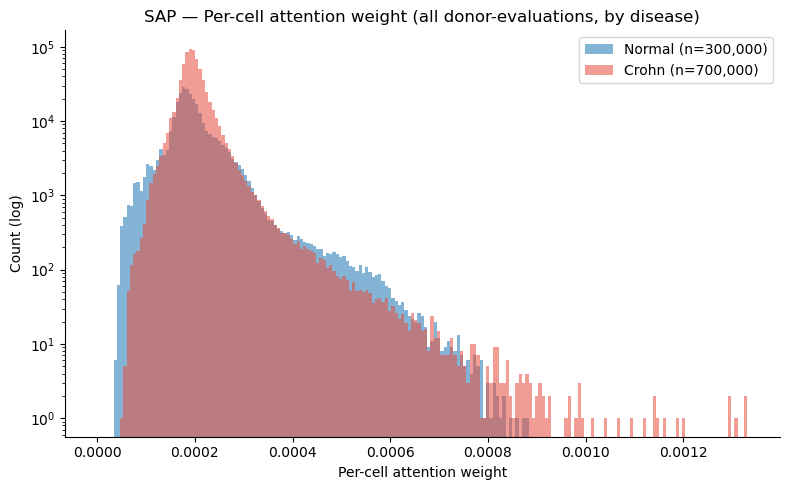

Saved -> results/sap_celltype_importance/fig_dist_per_cell_by_disease.png


In [9]:
ws_n = np.concatenate([r["weights"] for r in all_records if r["disease"]=="Normal"])
ws_c = np.concatenate([r["weights"] for r in all_records if r["disease"]=="Inflamed"])

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, max(ws_n.max(), ws_c.max()), 200)
ax.hist(ws_n, bins=bins, alpha=0.55, color=DISEASE_PALETTE["Normal"], label=f"Normal (n={len(ws_n):,})")
ax.hist(ws_c, bins=bins, alpha=0.55, color=DISEASE_PALETTE["Inflamed"], label=f"Inflamed (n={len(ws_c):,})")
ax.set_yscale("log"); ax.set_xlabel("Per-cell attention weight"); ax.set_ylabel("Count (log)")
ax.set_title("SAP — Per-cell attention weight (all donor-evaluations, by disease)")
ax.legend(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "fig_dist_per_cell_by_disease.png")
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
print("Saved ->", out)


## Distribution Plot 3 — Mean attention per cell type, per seed

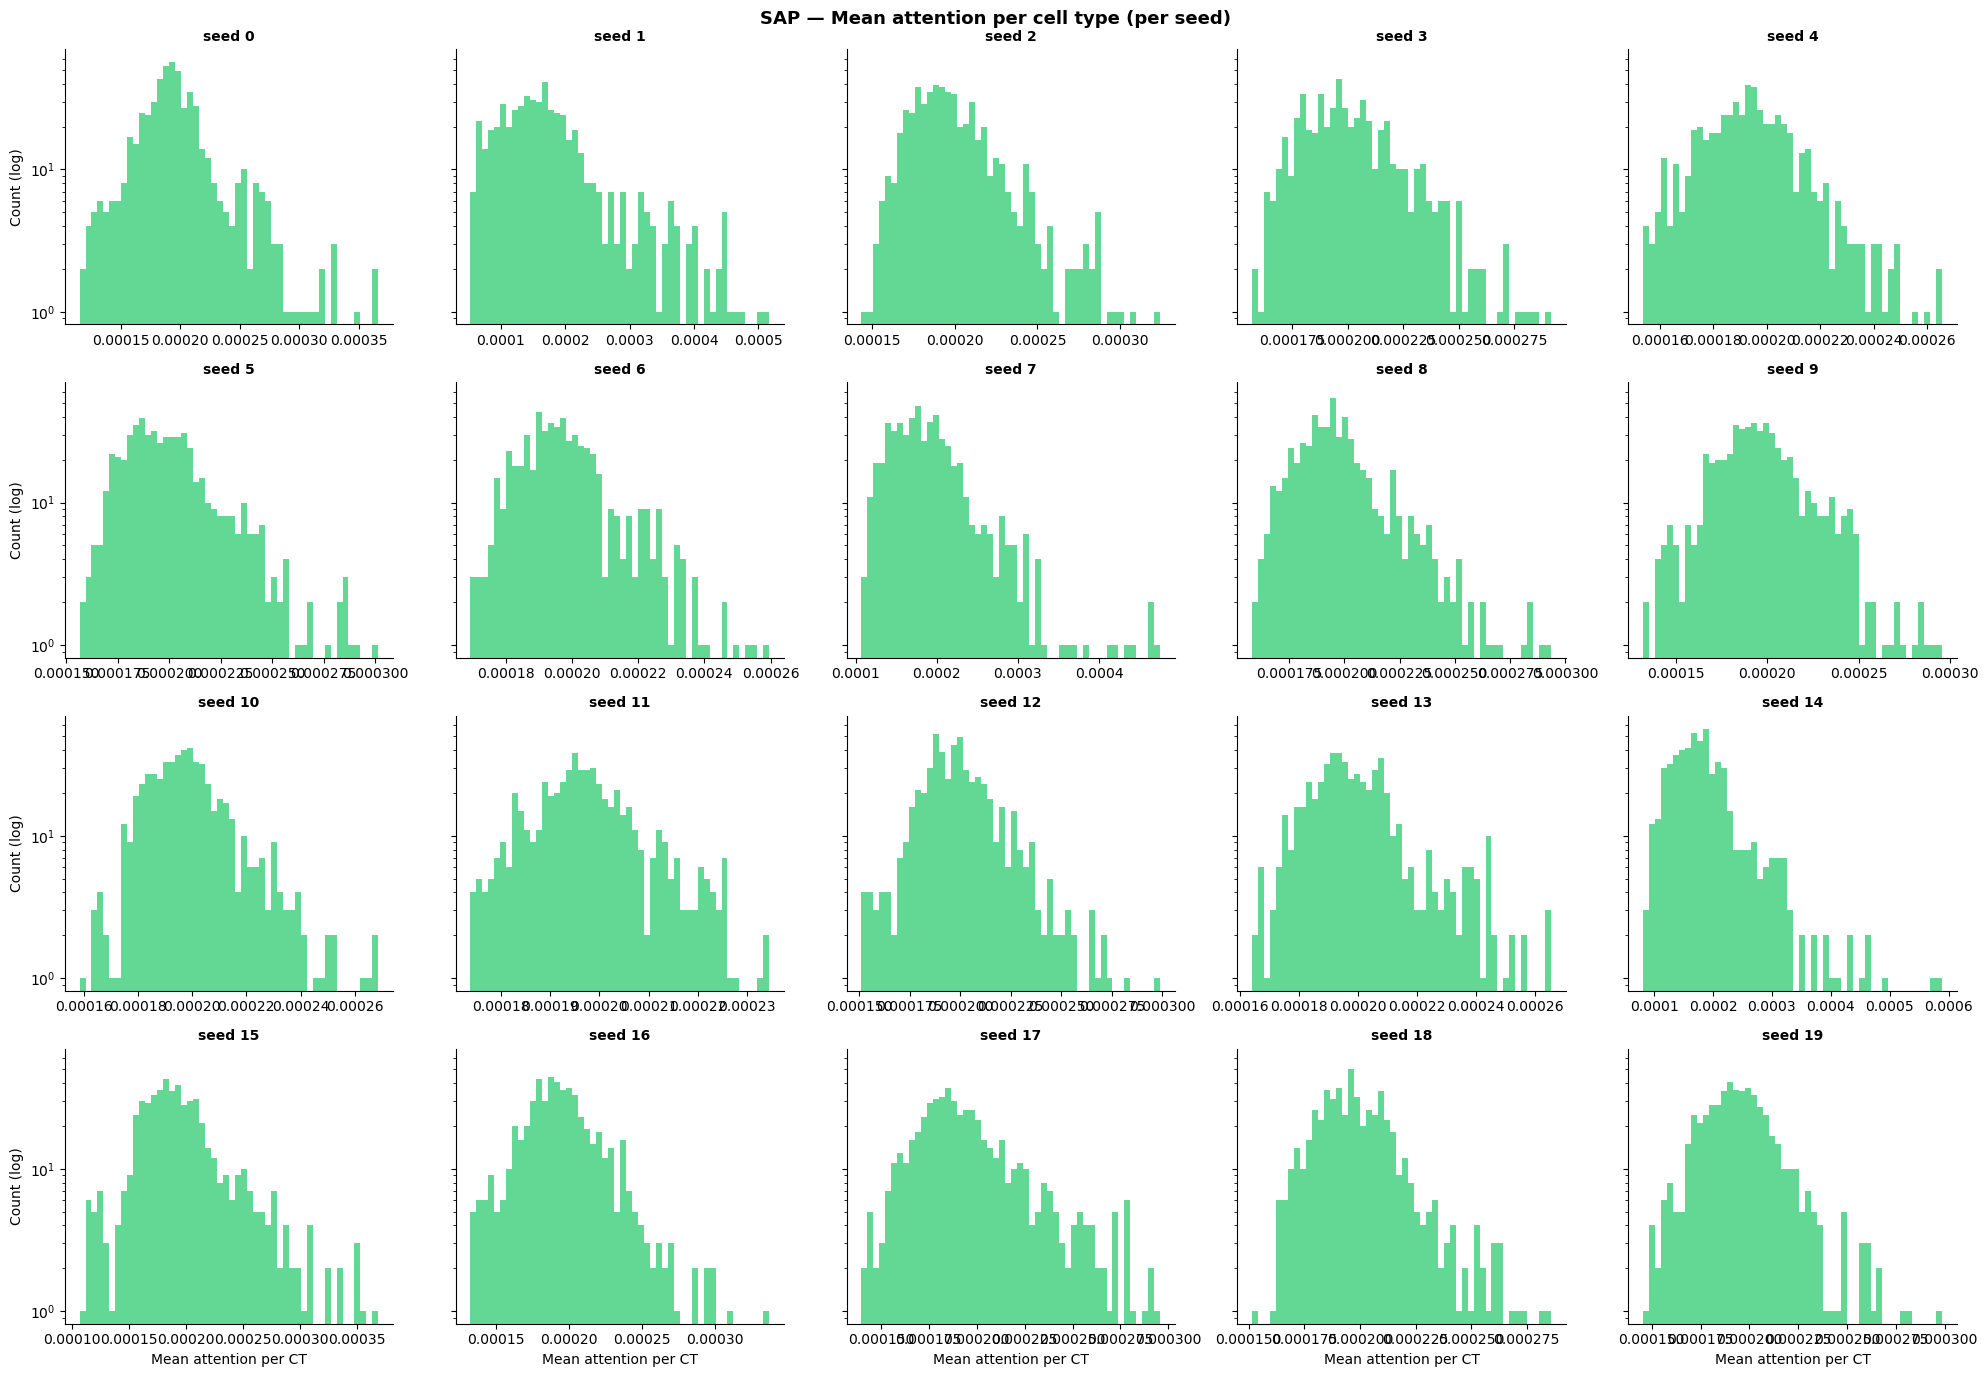

Saved -> results/sap_celltype_importance/fig_dist_mean_per_celltype_per_seed.png


In [10]:
fig, axes = plt.subplots(4, 5, figsize=(20, 14), sharey=True)
for ax, s in zip(axes.flat, SEEDS):
    vals = df_mean.loc[df_mean["seed"]==s, "mean_attention"].values
    if len(vals):
        ax.hist(vals, bins=50, color="#2ecc71", alpha=0.75, edgecolor="none")
    ax.set_title(f"seed {s}", fontsize=10, fontweight="bold")
    ax.set_yscale("log")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
for ax in axes[-1,:]: ax.set_xlabel("Mean attention per CT")
for ax in axes[:,0]:  ax.set_ylabel("Count (log)")
fig.suptitle("SAP — Mean attention per cell type (per seed)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "fig_dist_mean_per_celltype_per_seed.png")
plt.savefig(out, dpi=140, bbox_inches="tight"); plt.show()
print("Saved ->", out)


## 80% Cumulative Attention Mass — per seed + combined

In [11]:
cum_records = []
for r in all_records:
    sw = np.sort(r["weights"])[::-1]
    cs = np.cumsum(sw)
    k = int(np.searchsorted(cs, THRESHOLD) + 1)
    cum_records.append({
        "seed": r["seed"], "donor_id": r["donor_id"], "disease": r["disease"],
        "n_cells_total": r["n_cells"], "n_cells_80pct": k,
        "pct_cells_80pct": 100.0 * k / r["n_cells"],
    })
df_cum = pd.DataFrame(cum_records)
df_cum.to_csv(os.path.join(OUTPUT_DIR, "sap_attention_80pct_mass.csv"), index=False, float_format="%.3f")

print("Overall summary:")
print(f"  Mean cells for 80%: {df_cum['n_cells_80pct'].mean():.1f} / {df_cum['n_cells_total'].mean():.0f}")
print(f"  Mean %            : {df_cum['pct_cells_80pct'].mean():.2f}%")
print(f"  Median %          : {df_cum['pct_cells_80pct'].median():.2f}%")
print(f"  Range             : {df_cum['pct_cells_80pct'].min():.2f}% - {df_cum['pct_cells_80pct'].max():.2f}%")


Overall summary:
  Mean cells for 80%: 3766.4 / 5000
  Mean %            : 75.33%
  Median %          : 76.90%
  Range             : 50.58% - 79.10%


## Per-seed cumulative attention curves (20-panel)

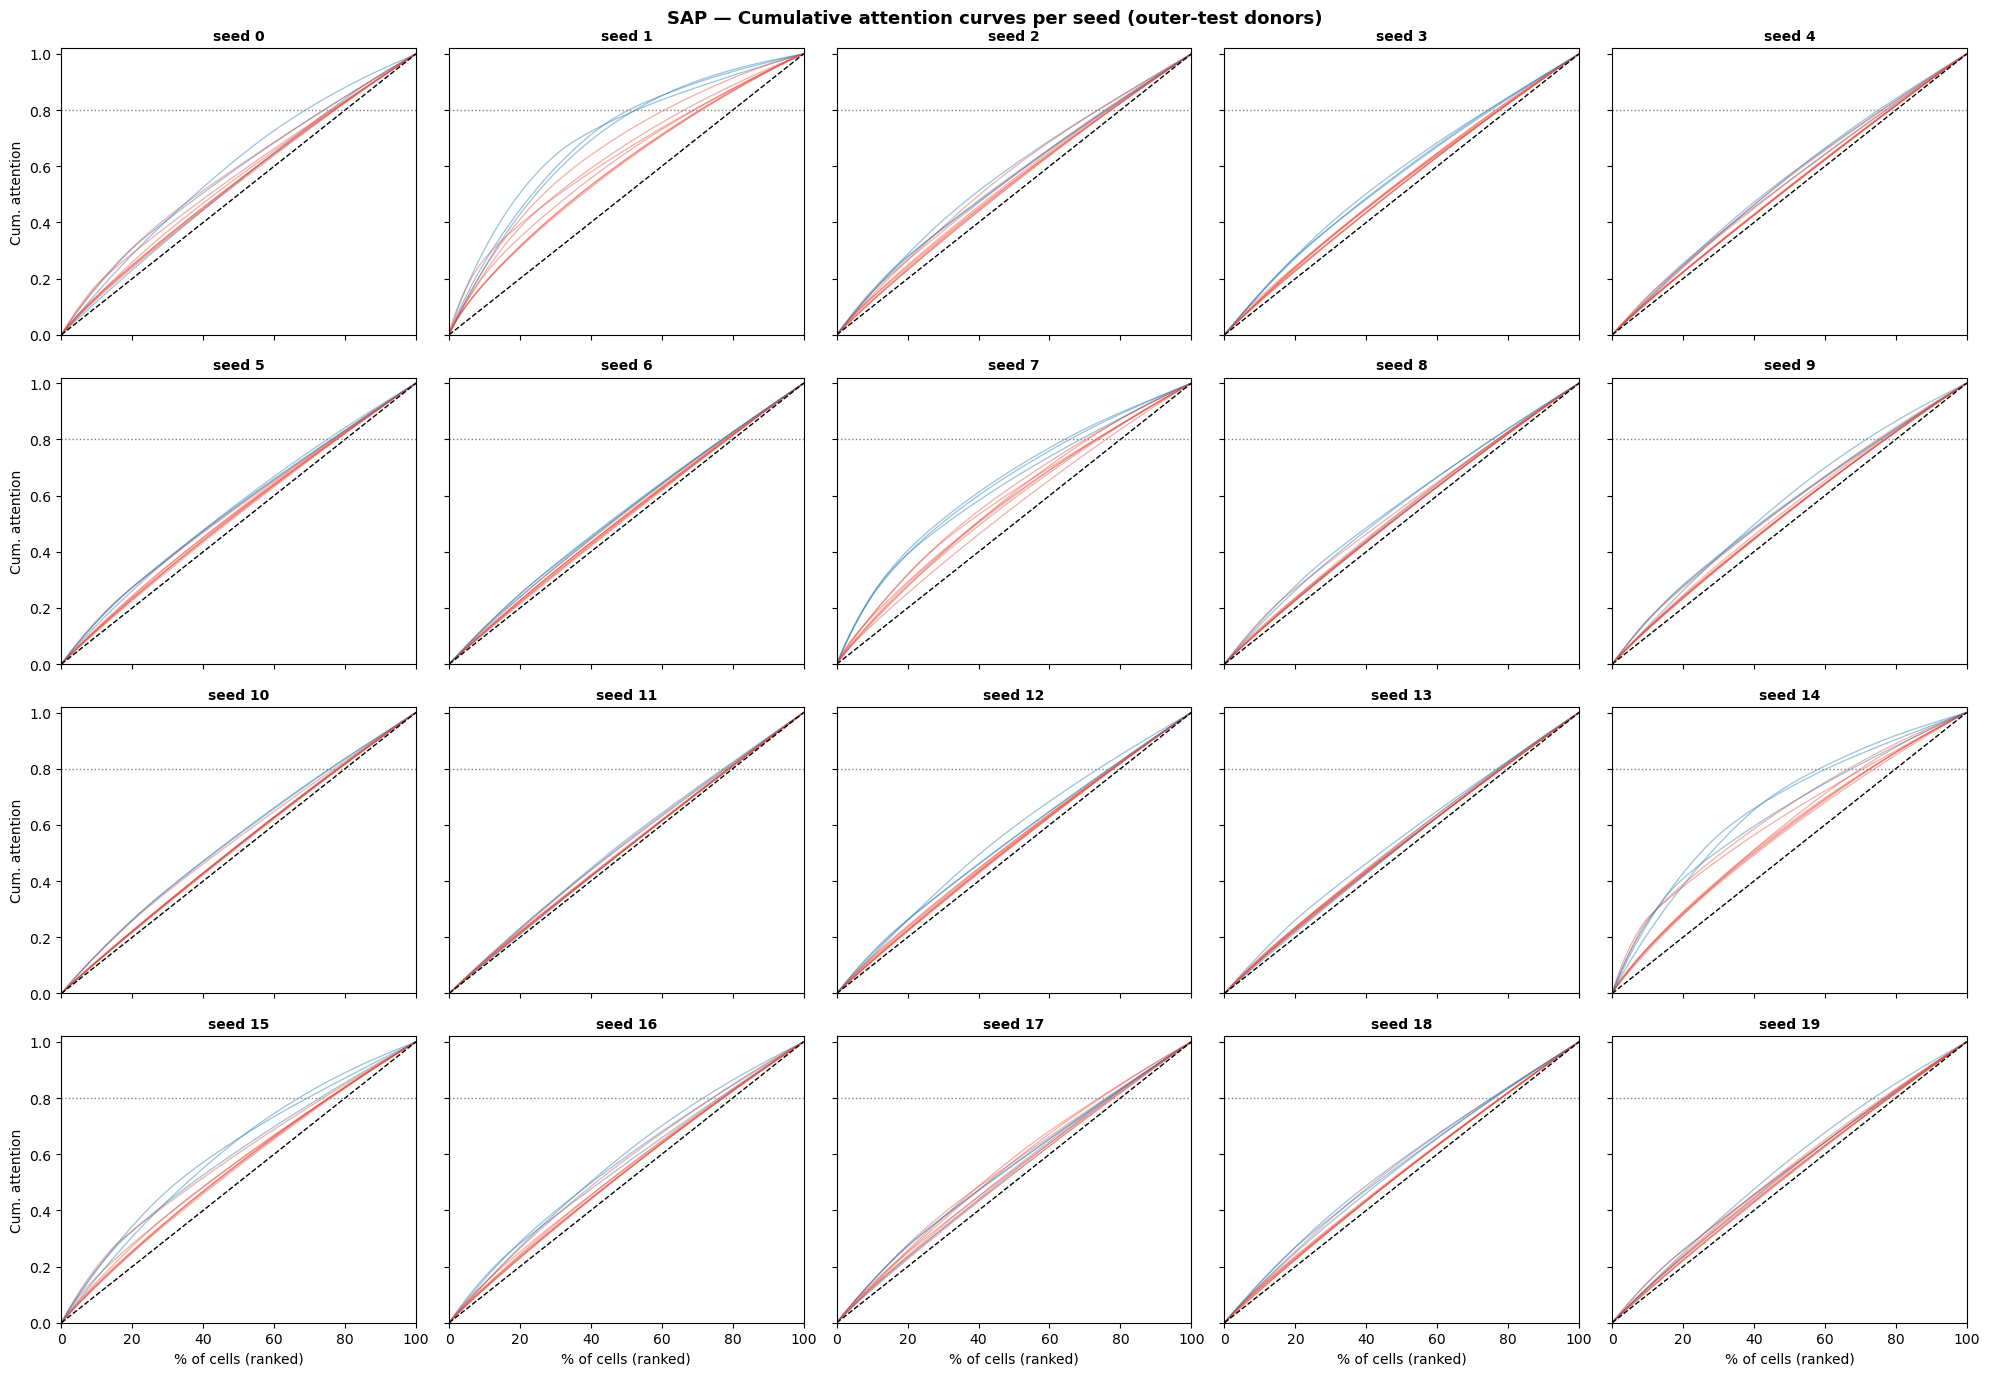

Saved -> results/sap_celltype_importance/fig_cum_curves_per_seed.png


In [12]:
fig, axes = plt.subplots(4, 5, figsize=(20, 14), sharex=True, sharey=True)
for ax, s in zip(axes.flat, SEEDS):
    seed_records = [r for r in all_records if r["seed"] == s]
    for r in seed_records:
        sw = np.sort(r["weights"])[::-1]
        cs = np.cumsum(sw)
        x = np.arange(1, len(sw)+1) / len(sw) * 100
        ax.plot(x, cs, color=DISEASE_PALETTE[r["disease"]], alpha=0.45, lw=0.9)
    ax.plot([0,100],[0,1], color="black", linestyle="--", lw=1)
    ax.axhline(THRESHOLD, color="gray", linestyle=":", lw=1)
    ax.set_title(f"seed {s}", fontsize=10, fontweight="bold")
    ax.set_xlim(0,100); ax.set_ylim(0,1.02)
for ax in axes[-1,:]: ax.set_xlabel("% of cells (ranked)")
for ax in axes[:,0]:  ax.set_ylabel("Cum. attention")
fig.suptitle("SAP — Cumulative attention curves per seed (outer-test donors)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "fig_cum_curves_per_seed.png")
plt.savefig(out, dpi=140, bbox_inches="tight"); plt.show()
print("Saved ->", out)


## Combined cumulative curves — all (seed, donor) overlaid

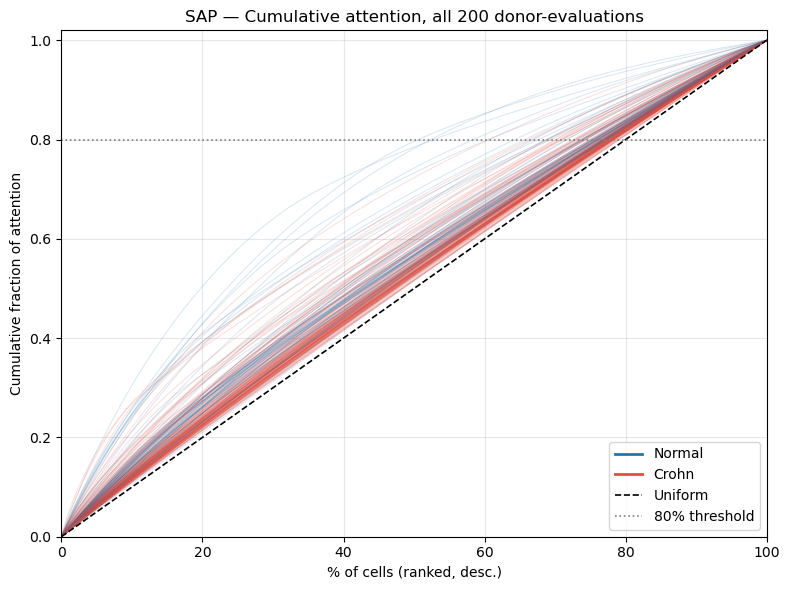

Saved -> results/sap_celltype_importance/fig_cum_curves_combined.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
for r in all_records:
    sw = np.sort(r["weights"])[::-1]
    cs = np.cumsum(sw)
    x = np.arange(1, len(sw)+1) / len(sw) * 100
    ax.plot(x, cs, color=DISEASE_PALETTE[r["disease"]], alpha=0.18, lw=0.7)
ax.plot([0,100],[0,1], color="black", linestyle="--", lw=1.2, label="Uniform")
ax.axhline(THRESHOLD, color="gray", linestyle=":", lw=1.2, label=f"{int(THRESHOLD*100)}% threshold")

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color=DISEASE_PALETTE["Normal"], lw=2, label="Normal"),
    Line2D([0],[0], color=DISEASE_PALETTE["Inflamed"], lw=2, label="Inflamed"),
    Line2D([0],[0], color="black", linestyle="--", lw=1.2, label="Uniform"),
    Line2D([0],[0], color="gray", linestyle=":", lw=1.2, label="80% threshold"),
], loc="lower right")
ax.set_xlabel("% of cells (ranked, desc.)"); ax.set_ylabel("Cumulative fraction of attention")
ax.set_title(f"SAP — Cumulative attention, all {len(all_records)} donor-evaluations")
ax.set_xlim(0,100); ax.set_ylim(0,1.02); ax.grid(alpha=0.3)
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "fig_cum_curves_combined.png")
plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
print("Saved ->", out)


## Top-20 cell types by mean attention (across all donor-evaluations)

In [14]:
top_overall = (df_mean.groupby("cell_type")["mean_attention"]
               .agg(mean_attn="mean", std_attn="std", n="size")
               .sort_values("mean_attn", ascending=False))
top_overall.round(6).to_csv(os.path.join(OUTPUT_DIR, "sap_top_celltypes_by_mean_attention.csv"),
                            float_format="%.6f")
print("Top 20:")
print(top_overall.head(20).round(5))


Top 20:
                                mean_attn  std_attn    n
cell_type                                               
Enterocytes CA1 CA2 CA4-          0.00028   0.00007  103
Enterocytes TMIGD1 MEP1A          0.00026   0.00005  200
Stem cells OLFM4 LGR5             0.00025   0.00005  200
Stem cells OLFM4 GSTA1            0.00025   0.00005  112
Enterocytes BEST4                 0.00025   0.00004  200
Stem cells OLFM4                  0.00025   0.00004  200
Stem cells OLFM4 PCNA             0.00024   0.00004  200
Enterocytes TMIGD1 MEP1A GSTA1    0.00024   0.00004  112
Epithelial Cycling cells          0.00024   0.00004  200
Pericytes RERGL NTRK2             0.00022   0.00002  157
Myofibroblasts HHIP NPNT          0.00021   0.00002  200
Enteroendocrine cells             0.00021   0.00002  103
Epithelial HBB HBA                0.00021   0.00004   96
Goblet cells SPINK4               0.00021   0.00002  192
Myofibroblasts GREM1 GREM2        0.00021   0.00002  181
L cells                

## Inflamed vs Normal — per-celltype attention comparison

**Method:** for each cell-type, aggregate the **per-donor mean per-cell attention**
(`mean_attention` already in `df_mean`) across the 20 seeds so each donor contributes
one independent value. Then run **Mann–Whitney U** (two-sided) between Inflamed and Normal
donors and apply **Benjamini–Hochberg FDR** across all tested cell-types. Boxplot shows the
per-donor distribution for the top-20 significant cell-types by |effect|, outliers hidden.


Cell-types tested: 65
Significant at FDR<0.05: 27

Top 15 by FDR:
                            cell_type  mean_crohn  mean_normal     diff  p_value  q_value_BH
                            DC2 CD1D-    0.000182     0.000162 0.000020 0.000123    0.005244
                                  DC1    0.000178     0.000160 0.000018 0.000323    0.005244
                    T cells CD8 KLRG1    0.000186     0.000169 0.000016 0.000210    0.005244
                    T cells Naive CD4    0.000189     0.000174 0.000015 0.000323    0.005244
                          T cells CD8    0.000187     0.000172 0.000014 0.000738    0.005462
                           Mast cells    0.000187     0.000168 0.000019 0.000533    0.005462
                          Glial cells    0.000206     0.000192 0.000014 0.000756    0.005462
                     T cells CD4 FOSB    0.000186     0.000171 0.000015 0.000738    0.005462
                                Tregs    0.000184     0.000170 0.000014 0.000628    0.005462
    

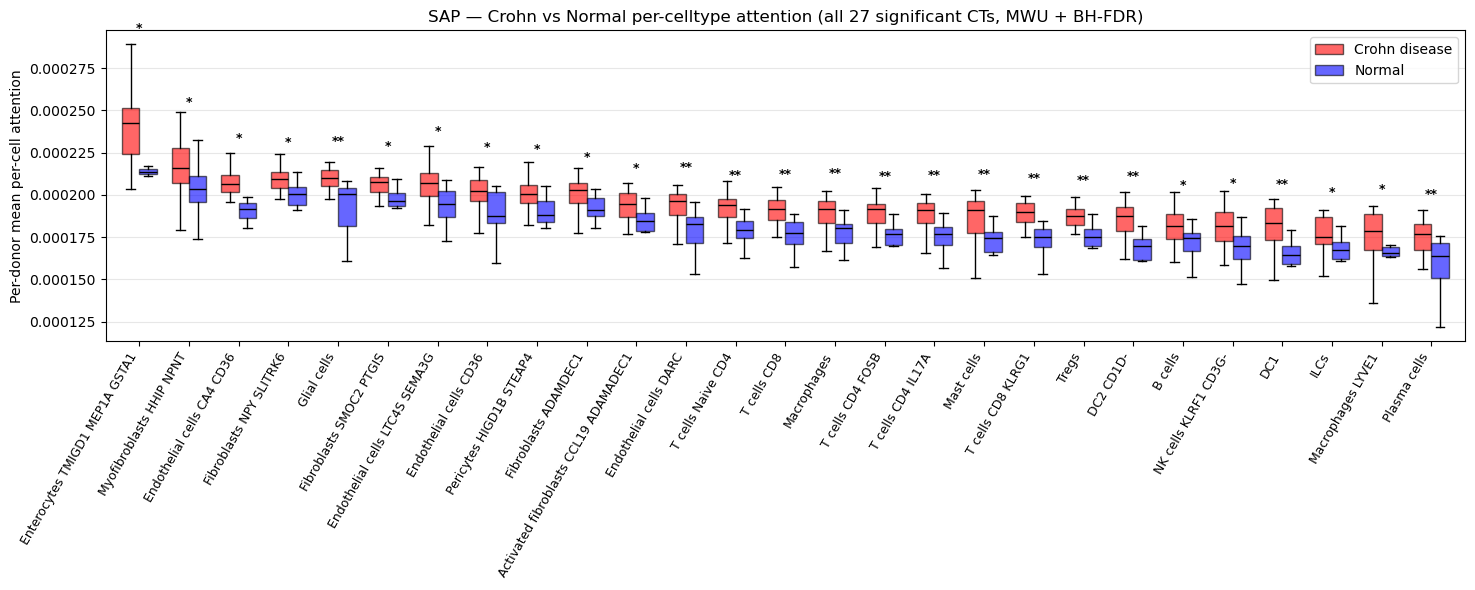


Saved -> results/sap_celltype_importance/sap_celltype_crohn_vs_normal_boxplot.png


In [15]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# One value per (donor, cell_type) = mean across seeds
per_donor_attn = (df_mean.groupby(["donor_id","disease","cell_type"], as_index=False)["mean_attention"]
                          .mean())

stats_rows = []
for ct, sub in per_donor_attn.groupby("cell_type"):
    inflamed = sub.loc[sub["disease"]=="Inflamed", "mean_attention"].values
    normal = sub.loc[sub["disease"]=="Normal",        "mean_attention"].values
    if len(inflamed) < 2 or len(normal) < 2:
        continue
    stat, p = mannwhitneyu(inflamed, normal, alternative="two-sided")
    stats_rows.append({
        "cell_type":    ct,
        "n_inflamed":      len(inflamed), "n_normal": len(normal),
        "mean_inflamed":   inflamed.mean(),  "mean_normal":  normal.mean(),
        "median_inflamed": float(np.median(inflamed)), "median_normal": float(np.median(normal)),
        "diff":         inflamed.mean() - normal.mean(),
        "U":            stat, "p_value": p,
    })
attn_stats_df = pd.DataFrame(stats_rows)
attn_stats_df["q_value_BH"] = multipletests(attn_stats_df["p_value"], method="fdr_bh")[1]
attn_stats_df["significant_q05"] = attn_stats_df["q_value_BH"] < 0.05
attn_stats_df = attn_stats_df.sort_values("q_value_BH")
attn_stats_df.round(6).to_csv(os.path.join(OUTPUT_DIR, "sap_celltype_inflamed_vs_normal_stats.csv"),
                              index=False, float_format="%.6f")

n_sig = int(attn_stats_df["significant_q05"].sum())
print(f"Cell-types tested: {len(attn_stats_df)}")
print(f"Significant at FDR<0.05: {n_sig}")
print("\nTop 15 by FDR:")
print(attn_stats_df[["cell_type","mean_inflamed","mean_normal","diff","p_value","q_value_BH"]]
      .head(15).round(6).to_string(index=False))

# Plot ALL significant cell-types (fallback: top 20 by FDR if none significant)
sig_df = attn_stats_df[attn_stats_df["significant_q05"]].copy()
if len(sig_df) == 0:
    sig_df = attn_stats_df.head(20).copy()
cts_to_plot = sig_df["cell_type"].tolist()

plot_long = per_donor_attn[per_donor_attn["cell_type"].isin(cts_to_plot)].copy()
order = (plot_long.groupby("cell_type")["mean_attention"].mean()
                  .reindex(cts_to_plot).sort_values(ascending=False).index.tolist())

# Persist for downstream proportion plots so they use the SAME cell-types in the SAME order
SIG_CTS_ORDER = order

fig, ax = plt.subplots(figsize=(max(10, 0.55*len(order)), 6))
positions = np.arange(len(order)); width = 0.35
box_inflamed = ax.boxplot(
    [plot_long[(plot_long.cell_type==c)&(plot_long.disease=="Inflamed")]["mean_attention"].values
     for c in order],
    positions=positions-width/2, widths=width, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="red", alpha=0.6, edgecolor="black"),
    medianprops=dict(color="black"))
box_normal = ax.boxplot(
    [plot_long[(plot_long.cell_type==c)&(plot_long.disease=="Normal")]["mean_attention"].values
     for c in order],
    positions=positions+width/2, widths=width, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="blue", alpha=0.6, edgecolor="black"),
    medianprops=dict(color="black"))

ymax_per_ct = plot_long.groupby("cell_type")["mean_attention"].quantile(0.95).reindex(order).values
for i, ct in enumerate(order):
    q = attn_stats_df.loc[attn_stats_df["cell_type"]==ct, "q_value_BH"].iloc[0]
    mark = "***" if q<0.001 else "**" if q<0.01 else "*" if q<0.05 else "ns"
    ax.text(i, ymax_per_ct[i]*1.05, mark, ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(positions); ax.set_xticklabels(order, rotation=60, ha="right", fontsize=9)
ax.set_ylabel("Per-donor mean per-cell attention")
ax.set_title(f"SAP — Inflamed vs Normal per-celltype attention (all {len(order)} significant CTs, MWU + BH-FDR)")
ax.legend([box_inflamed["boxes"][0], box_normal["boxes"][0]], ["Inflamed","Normal"], loc="best")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "sap_celltype_inflamed_vs_normal_boxplot.png")
plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
print(f"\nSaved -> {out}")


## Inflamed vs Normal — cell-count proportions for the same significant CTs

Per-donor `proportion = (# cells of CT in donor) / (total cells in donor)`. Mann–Whitney U with
BH-FDR on the same top-20 cell-types from the attention boxplot above. Outliers hidden.


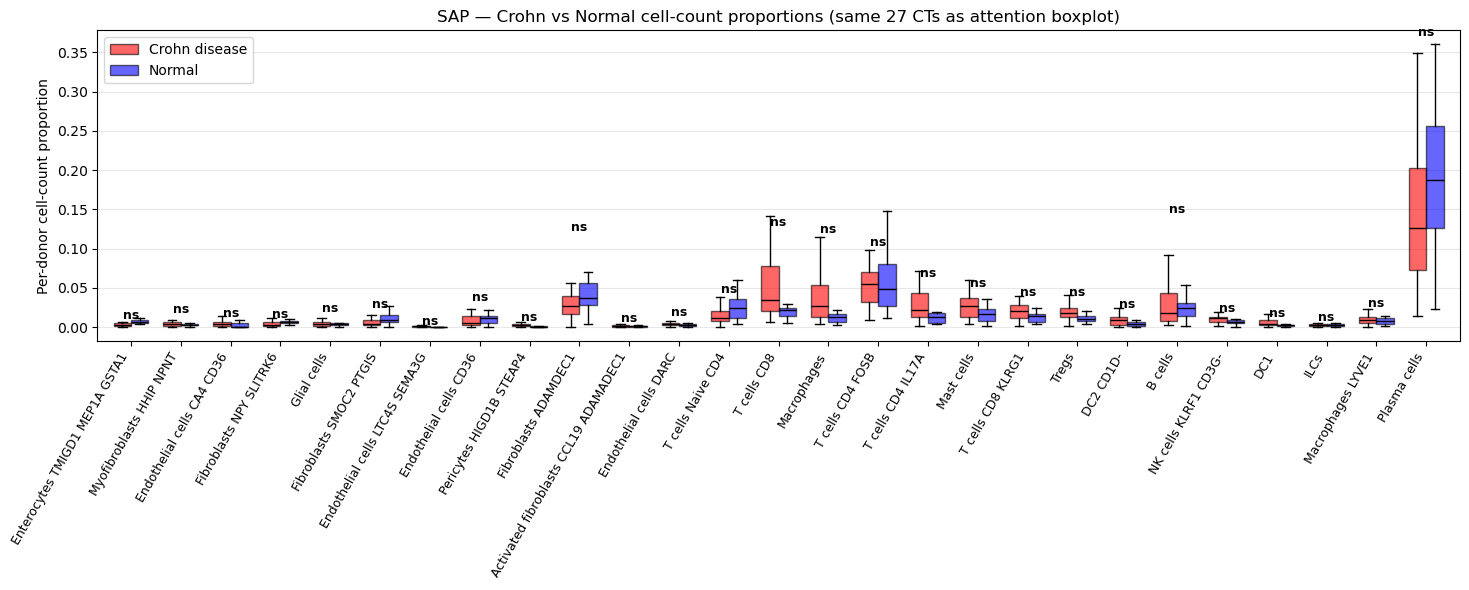

Saved -> results/sap_celltype_importance/sap_celltype_count_proportions_boxplot.png

Proportion stats (same 27 CTs):
                            cell_type  mean_crohn  mean_normal      diff  p_value  q_value_BH
                          T cells CD8    0.051172     0.020214  0.030958 0.009516    0.051386
                          Macrophages    0.042489     0.012200  0.030289 0.005866    0.051386
                                Tregs    0.020539     0.011957  0.008582 0.009211    0.051386
                    T cells CD4 IL17A    0.028739     0.012086  0.016653 0.005867    0.051386
                 NK cells KLRF1 CD3G-    0.011039     0.006329  0.004710 0.006679    0.051386
                                  DC1    0.005661     0.002729  0.002933 0.013275    0.054486
              Fibroblasts NPY SLITRK6    0.004056     0.006517 -0.002461 0.014126    0.054486
       Endothelial cells LTC4S SEMA3G    0.001406     0.000800  0.000606 0.020598    0.061793
                            DC2 CD1D-

In [16]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Per-donor cell-count proportion table (built from donor_ct_lookup + samples)
prop_rows = []
for did, ct_arr in donor_ct_lookup.items():
    row = samples[samples["patient"] == did]
    if row.empty: continue
    dis = LABEL_NAMES[int(row.iloc[0]["label"])]
    n = len(ct_arr)
    u, counts = np.unique(ct_arr, return_counts=True)
    for cc, cnt in zip(u, counts):
        prop_rows.append({"donor_id": did, "disease": dis, "cell_type": cc,
                          "prop": cnt / n})
per_donor_prop = pd.DataFrame(prop_rows)

# Use the EXACT same set + order of cell-types as the attention boxplot above
plot_cts = list(SIG_CTS_ORDER)
order_p  = plot_cts

prop_stats = []
for ct in plot_cts:
    sub = per_donor_prop[per_donor_prop["cell_type"]==ct]
    cr = sub.loc[sub["disease"]=="Inflamed","prop"].values
    nm = sub.loc[sub["disease"]=="Normal","prop"].values
    if len(cr) < 2 or len(nm) < 2:
        p = np.nan
    else:
        _, p = mannwhitneyu(cr, nm, alternative="two-sided")
    prop_stats.append({"cell_type": ct,
                       "mean_inflamed":  cr.mean() if len(cr) else np.nan,
                       "mean_normal": nm.mean() if len(nm) else np.nan,
                       "diff": (cr.mean() if len(cr) else np.nan) - (nm.mean() if len(nm) else np.nan),
                       "p_value": p})
prop_stats_df = pd.DataFrame(prop_stats)
ok = ~prop_stats_df["p_value"].isna()
prop_stats_df.loc[ok, "q_value_BH"] = multipletests(prop_stats_df.loc[ok, "p_value"],
                                                    method="fdr_bh")[1]
prop_stats_df.round(4).to_csv(os.path.join(OUTPUT_DIR, "sap_celltype_count_proportions_stats.csv"),
                              index=False, float_format="%.4f")

fig, ax = plt.subplots(figsize=(max(10, 0.55*len(order_p)), 6))
positions = np.arange(len(order_p)); width = 0.35
box_inflamed = ax.boxplot(
    [per_donor_prop[(per_donor_prop.cell_type==c)&(per_donor_prop.disease=="Inflamed")]["prop"].values
     for c in order_p],
    positions=positions-width/2, widths=width, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="red", alpha=0.6, edgecolor="black"),
    medianprops=dict(color="black"))
box_normal = ax.boxplot(
    [per_donor_prop[(per_donor_prop.cell_type==c)&(per_donor_prop.disease=="Normal")]["prop"].values
     for c in order_p],
    positions=positions+width/2, widths=width, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="blue", alpha=0.6, edgecolor="black"),
    medianprops=dict(color="black"))

ymax_per_ct = (per_donor_prop[per_donor_prop.cell_type.isin(order_p)]
               .groupby("cell_type")["prop"].quantile(0.95).reindex(order_p).values)
for i, ct in enumerate(order_p):
    q = prop_stats_df.loc[prop_stats_df["cell_type"]==ct, "q_value_BH"].iloc[0]
    if pd.isna(q):  mark = "n/a"
    elif q<0.001:    mark = "***"
    elif q<0.01:     mark = "**"
    elif q<0.05:     mark = "*"
    else:            mark = "ns"
    ax.text(i, ymax_per_ct[i]*1.05, mark, ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(positions); ax.set_xticklabels(order_p, rotation=60, ha="right", fontsize=9)
ax.set_ylabel("Per-donor cell-count proportion")
ax.set_title(f"SAP — Inflamed vs Normal cell-count proportions (same {len(order_p)} CTs as attention boxplot)")
ax.legend([box_inflamed["boxes"][0], box_normal["boxes"][0]], ["Inflamed","Normal"], loc="best")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "sap_celltype_count_proportions_boxplot.png")
plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
print(f"Saved -> {out}")
print(f"\nProportion stats (same {len(order_p)} CTs):")
print(prop_stats_df.sort_values("q_value_BH").to_string(index=False))


## Same boxplot — log-scale y-axis

Log-scale view; zeros are replaced with a pseudocount (half the smallest non-zero proportion).


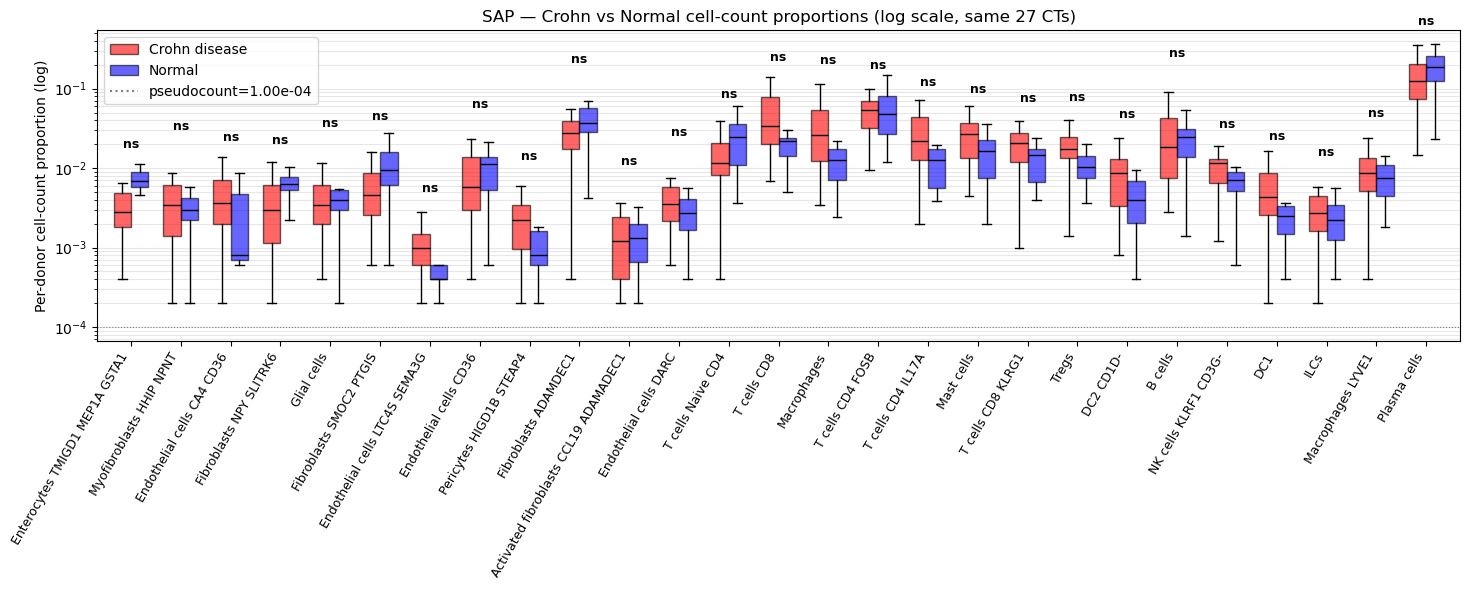

Saved -> results/sap_celltype_importance/sap_celltype_count_proportions_boxplot_log.png


In [17]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

nonzero_min = per_donor_prop.loc[per_donor_prop["prop"] > 0, "prop"].min()
pseudo = nonzero_min / 2
plot_df = per_donor_prop.copy()
plot_df["prop_log"] = plot_df["prop"].where(plot_df["prop"] > 0, pseudo)

fig, ax = plt.subplots(figsize=(max(10, 0.55*len(order_p)), 6))
positions = np.arange(len(order_p)); width = 0.35
box_inflamed = ax.boxplot(
    [plot_df[(plot_df.cell_type==c)&(plot_df.disease=="Inflamed")]["prop_log"].values
     for c in order_p],
    positions=positions-width/2, widths=width, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="red", alpha=0.6, edgecolor="black"),
    medianprops=dict(color="black"))
box_normal = ax.boxplot(
    [plot_df[(plot_df.cell_type==c)&(plot_df.disease=="Normal")]["prop_log"].values
     for c in order_p],
    positions=positions+width/2, widths=width, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="blue", alpha=0.6, edgecolor="black"),
    medianprops=dict(color="black"))
ax.set_yscale("log")

ymax_per_ct = (plot_df[plot_df.cell_type.isin(order_p)]
               .groupby("cell_type")["prop_log"].quantile(0.95).reindex(order_p).values)
for i, ct in enumerate(order_p):
    q = prop_stats_df.loc[prop_stats_df["cell_type"]==ct, "q_value_BH"].iloc[0]
    if pd.isna(q):  mark = "n/a"
    elif q<0.001:    mark = "***"
    elif q<0.01:     mark = "**"
    elif q<0.05:     mark = "*"
    else:            mark = "ns"
    ax.text(i, ymax_per_ct[i]*1.8, mark, ha="center", fontsize=9, fontweight="bold")

ax.axhline(pseudo, color="gray", linestyle=":", linewidth=0.8,
           label=f"pseudocount = {pseudo:.2e} (for zeros)")

ax.set_xticks(positions); ax.set_xticklabels(order_p, rotation=60, ha="right", fontsize=9)
ax.set_ylabel("Per-donor cell-count proportion (log)")
ax.set_title(f"SAP — Inflamed vs Normal cell-count proportions (log scale, same {len(order_p)} CTs)")
ax.legend([box_inflamed["boxes"][0], box_normal["boxes"][0],
           plt.Line2D([0],[0], color="gray", linestyle=":")],
          ["Inflamed","Normal", f"pseudocount={pseudo:.2e}"], loc="best")
ax.grid(axis="y", which="both", alpha=0.3); plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "sap_celltype_count_proportions_boxplot_log.png")
plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
print(f"Saved -> {out}")


## Direction summary table — significant CTs

For each cell-type significant in the **attention** test (FDR < 0.05), tick which of the four
categories it belongs to based on the sign of `diff = mean_inflamed - mean_normal`.
Ordering: (1) higher attention & higher proportion in Inflamed, (2) higher attention & higher proportion in Normal,
(3) attention/proportion direction disagreement at the end. Within each block: by |attention diff| desc.

In [18]:
import pandas as pd

attn = pd.read_csv("results/sap_celltype_importance/sap_celltype_inflamed_vs_normal_stats.csv")
prop = pd.read_csv("results/sap_celltype_importance/sap_celltype_count_proportions_stats.csv")

sig = attn[attn["significant_q05"]].copy()
sig = sig.merge(prop[["cell_type", "diff", "q_value_BH"]]
                  .rename(columns={"diff": "prop_diff", "q_value_BH": "prop_q"}),
                on="cell_type", how="left")

TICK = "\u2713"
table = pd.DataFrame({
    "cell_type":                   sig["cell_type"],
    "higher_attention_in_Inflamed":   [TICK if d > 0 else "" for d in sig["diff"]],
    "higher_proportion_in_Inflamed":  [TICK if (pd.notna(d) and d > 0) else "" for d in sig["prop_diff"]],
    "higher_attention_in_Normal":  [TICK if d < 0 else "" for d in sig["diff"]],
    "higher_proportion_in_Normal": [TICK if (pd.notna(d) and d < 0) else "" for d in sig["prop_diff"]],
    "proportion_significant_q05":  [TICK if (pd.notna(q) and q < 0.05) else "" for q in sig["prop_q"]],
})

def _grp(row):
    a, p = row["diff"], row["prop_diff"]
    if pd.isna(p):              return 3
    if a > 0 and p > 0:         return 0  # both Inflamed
    if a < 0 and p < 0:         return 1  # both Normal
    return 2                                # disagreement
sig_sorted = sig.assign(
    _grp=sig.apply(_grp, axis=1),
    _key=sig["diff"].abs()
).sort_values(["_grp", "_key"], ascending=[True, False])
table = table.set_index("cell_type").reindex(sig_sorted["cell_type"]).reset_index()

out_csv = "results/sap_celltype_importance/sap_celltype_direction_summary.csv"
table.to_csv(out_csv, index=False)
print(f"Saved -> {out_csv}")
print(f"\nDirection summary for {len(table)} significant cell-types:\n")
print(table.to_string(index=False))

Saved -> results/sap_celltype_importance/sap_celltype_direction_summary.csv

Direction summary for 27 significant cell-types:

                            cell_type higher_attention_in_Crohn higher_proportion_in_Crohn higher_attention_in_Normal higher_proportion_in_Normal proportion_significant_q05
                            DC2 CD1D-                         ✓                          ✓                                                                                  
                           Mast cells                         ✓                          ✓                                                                                  
                                  DC1                         ✓                          ✓                                                                                  
                    T cells CD8 KLRG1                         ✓                          ✓                                                                                  
        